# DSCI 160 — Open-Book Quiz Notes (Lectures 1–5)

**Purpose:** a fast, searchable reference for the quiz. Use **Ctrl/Cmd + F** to search a command or concept.

## Fast navigation

1. **Emergency cheat sheet** — syntax you may need immediately  
2. **Lecture 1** — Jupyter, imports, pandas, descriptive statistics, plots  
3. **Lecture 2** — types, variables, strings, lists, indexing, aliasing  
4. **Lecture 3** — type conversion, Boolean values, comparisons, logic  
5. **Lecture 4** — functions, methods, libraries, NumPy summaries  
6. **Lecture 5** — random, binomial/negative binomial, arrays, math, plotting  
7. **Common errors and traps**  
8. **Practice questions with answers**

> Run the setup cell once. Examples below are independent whenever practical.


In [1]:
# QUIZ SETUP — run this once
import math
import random
import statistics as statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats


# 1. Emergency cheat sheet

| Goal | Code | Key idea |
|---|---|---|
| Check an object's type | `type(x)` | Common types: `int`, `float`, `str`, `bool`, `list`, `np.ndarray` |
| Save a value | `x = 3` | Right side is evaluated first; `=` assigns |
| Test equality | `x == 3` | `==` compares; do not confuse with `=` |
| Convert types | `int("3")`, `float("3.2")`, `str(3)` | Conversion must be valid |
| List length | `len(my_list)` | Number of elements |
| Get list item | `my_list[0]` | Python starts at index 0 |
| Last list item | `my_list[-1]` | Negative indices count backward |
| Membership | `x in my_list` | Returns `True` or `False` |
| Copy a list | `new = old.copy()` | `new = old` creates an alias, not a copy |
| Add one list item | `my_list.append(x)` | Mutates the original list |
| Sort list | `my_list.sort()` | Mutates list; returns `None` |
| Load CSV | `df = pd.read_csv("file.csv")` | Creates a DataFrame |
| Select column | `df["column"]` | Returns a Series |
| Summaries | `df.describe()` | Numeric columns by default |
| Frequency table | `pd.crosstab(df["x"], "count")` | Counts categories |
| Scatter plot | `plt.scatter(x=x, y=y)` | Add labels and `plt.show()` |
| One random item | `random.choice(items)` | Single selection |
| Several, repeats allowed | `random.choices(items, k=5)` | With replacement |
| Several, no repeats | `random.sample(items, k=5)` | Without replacement |
| Random integer | `random.randint(a, b)` | Both endpoints included |
| Exactly `k` successes | `stats.binom.pmf(k, n, p)` | `n` trials, success probability `p` |
| `k` failures before `n` successes | `stats.nbinom.pmf(k, n, p)` | Negative binomial |
| Make NumPy array | `a = np.array([1, 2, 3])` | Enables elementwise math |

## Operator priority

Parentheses → exponent `**` → multiply/divide `* / // %` → add/subtract `+ -` → comparisons → `not` → `and` → `or`.

When unsure, **use parentheses**.


In [2]:
# Tiny syntax examples
x = 7
print(x == 7, x != 7, x > 3)

items = [10, 20, 30]
print(items[0], items[-1], 20 in items)

a = np.array([1, 2, 3])
print(a + 10)       # [11 12 13]
print(a * 2)        # [2 4 6]


True False True
10 30 True
[11 12 13]
[2 4 6]


# 2. Lecture 1 — Jupyter, packages, pandas, and plots

## Jupyter essentials

- A **code cell** executes Python. A **Markdown cell** contains formatted notes.
- In a code cell, only the last unassigned expression is automatically displayed. Use `print()` or `display()` for multiple outputs.
- `#` begins a comment in Python.
- The **kernel** is the Python process running the notebook. Variables exist only after their defining cells have run.
- If you restart the kernel, variables/imports disappear. Run cells again in order.

## Packages and imports

A package/library adds functionality. The alias after `as` is the name you must use afterward.

```python
import math
import statistics as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

Examples: `math.log2(8)`, `stats.mean(values)`, `np.sqrt(values)`, `pd.read_csv(...)`, `plt.scatter(...)`.

## Arithmetic

| Operator | Meaning | Example/result |
|---|---|---|
| `+`, `-`, `*` | addition, subtraction, multiplication | `3*4` → `12` |
| `/` | ordinary division | `35/8` → `4.375` |
| `//` | floor division | `35//8` → `4` |
| `%` | remainder | `35%8` → `3` |
| `**` | exponent | `2**3` → `8` |


In [3]:
# pandas templates — replace the file/column names
# df = pd.read_csv("data/features.csv")
# display(df)
# display(df["cylinders"])
# display(pd.crosstab(index=df["cylinders"], columns="count"))
# display(pd.crosstab(index=df["cylinders"], columns=df["mpg"]))
# display(df.describe())
# display(round(df.describe(), 2))
# display(df.describe(percentiles=[0.33, 0.66]))


### Reading pandas output

`df.describe()` returns `count`, `mean`, `std`, `min`, quartiles (`25%`, `50%`, `75%`), and `max` for numeric variables. Custom percentiles must be between 0 and 1: `percentiles=[.33, .66]`.

`pd.crosstab(index=..., columns=...)`:

- One categorical variable + constant column label (`"count"`) → frequency table.
- Two variables → counts for every pair of categories.

Use `help(function)` to see required/optional arguments, e.g. `help(pd.crosstab)` or `help(df.describe)`.

### Plot checklist

A readable plot normally needs the correct x/y data, labels, title, and `plt.show()`. Always verify labels match the actual variables—the original Lecture 1 practice cell accidentally mismatched some labels/data.


In [4]:
# Scatter-plot template
# plt.scatter(x=df["weight"], y=df["mpg"])
# plt.xlabel("Weight")
# plt.ylabel("Miles per gallon")
# plt.title("MPG versus vehicle weight")
# plt.show()

# A second plot should have its own commands and plt.show()
# plt.scatter(x=df["acceleration"], y=df["mpg"])
# plt.xlabel("Acceleration")
# plt.ylabel("Miles per gallon")
# plt.title("MPG versus acceleration")
# plt.show()


# 3. Lecture 2 — objects, variables, strings, and lists

## Core object types

- `int`: whole number, e.g. `3`, `-2`, `0`
- `float`: number with decimal/floating-point representation, e.g. `3.25`
- `str`: text, e.g. `"Hello"`
- `bool`: `True` or `False`
- `list`: ordered, mutable collection, e.g. `[1, "two", 3.0]`

`type(object)` reports the type. A function itself and the value returned by calling it are different: `type(math.sqrt)` is a function type; `type(math.sqrt(3))` is `float`.

## Assignment and variable names

In `x = expression`, Python evaluates the **right side first**, then assigns its result to `x`. Thus `x = x + 1` is valid: use old `x`, add 1, then replace `x`.

Names may contain letters, numbers, and `_`, but cannot start with a number or contain spaces. Names are case-sensitive: `last_name` and `Last_name` differ.

## Strings

- Single and double quotes both work.
- Use the other quote style or escape with `\` when a quote appears inside text.
- `\n` creates a new line.
- `+` concatenates strings: `"June" + " " + "Ouyang"`.
- Strings are indexed like lists but are **immutable**: `name[0] = "P"` causes an error.


In [5]:
first_name = "June"
major = "Economics and Computer Science"

# Remember spaces explicitly when concatenating
sentence = "I am " + first_name + " majoring in " + major
print(sentence)
print(first_name[0], first_name[-1])


I am June majoring in Economics and Computer Science
J e


## Lists and indexing

Python uses **zero-based indexing**:

| Expression | Meaning |
|---|---|
| `L[0]` | first item |
| `L[1]` | second item |
| `L[-1]` | last item |
| `L[-2]` | second-to-last item |
| `L[i][j]` | item `j` inside nested item `i` |
| `len(L)` | number of top-level items |

Lists are mutable, so `L[0] = new_value` changes the list.

### The aliasing trap

`b = a` does **not** copy a list. Both names point to the same object, so changing either name's list is visible through the other. Use `b = a.copy()` for a separate shallow copy.

When a single immutable element is assigned to a variable (`x = a[0]`), later replacing `a[0]` does not change `x`.


In [6]:
original = [2.3, -1.0, 5.1]
alias = original
copy_list = original.copy()

original[0] = "changed"
print(alias)       # changed too: same list object
print(copy_list)   # unchanged: separate list

nested = [7, 5, ["A", "B", "C"], "20", 20]
print(nested[2][1])  # B


['changed', -1.0, 5.1]
[2.3, -1.0, 5.1]
B


## Swapping values

The lecture uses a temporary variable. If you do `a = b` first, the old value of `a` is lost unless saved.


In [7]:
a = "left"
b = "right"
temp = a
a = b
b = temp
print(a, b)


right left


# 4. Lecture 3 — conversion, comparisons, and logic

## Type conversion

- `str(x)` → text
- `int(x)` → integer (only if conversion is valid)
- `float(x)` → floating-point number

`"10" + "2"` gives `"102"`, while `int("10") + int("2")` gives `12`.

Important examples:

- `int("2024")` works.
- `float("3.99")` works.
- `int("3.99")` fails because the string is not an integer literal. Use `int(float("3.99"))` only if truncation is intended.
- `int(True)` is `1`; `int(False)` is `0`.

Numeric versus string x-values may cause a graph to behave differently: numeric months use a numeric scale; string months are treated as ordered categories.

## Comparisons

| Operator | Meaning |
|---|---|
| `>` / `<` | greater / less than |
| `>=` / `<=` | greater/less than or equal |
| `==` | equal |
| `!=` | not equal |

String equality requires exact characters, including spaces and capitalization. List equality requires equal elements in equal order.


## Floating-point warning

Many decimal fractions cannot be represented exactly in binary. Therefore, avoid exact equality for calculated floats.

```python
x = 0.1 + 0.1 + 0.1
y = 0.3
x == y                 # False
abs(x - y) < 1e-13     # True: close enough for this context
```

`1e-13` means $1\times10^{-13}$. The appropriate tolerance depends on context. `np.isclose(x, y)` is another useful approach.

## Membership with `in`

- `substring in string` checks whether that exact character sequence occurs.
- `item in list` checks whether an equal item is in the list.
- Checks are case-sensitive: `"Federal"` and `"federal"` differ.

## Logical operators

| `p` | `q` | `p and q` | `p or q` | `p ^ q` |
|---|---|---|---|---|
| False | False | False | False | False |
| False | True | False | True | True |
| True | False | False | True | True |
| True | True | True | True | False |

- `not p`: reverses a Boolean.
- `and`: both conditions must be true.
- `or`: at least one must be true (inclusive OR).
- `^`: exactly one is true (exclusive OR for Booleans).
- Chained comparison: `10 < price <= 20` means `(10 < price) and (price <= 20)`.

**Use real Boolean values, not strings.** `has_exception = "False"` is a nonempty string and therefore truthy in a logical expression. Use `has_exception = False`.


In [8]:
price = 15
print((price > 10) and (price <= 20))
print(10 < price <= 20)  # equivalent

age = 21
has_exception = False
isolated_room = False

# Parentheses make the intended grouping explicit
allowed = (age > 18 or has_exception) and isolated_room
print(allowed)


True
True
False


# 5. Lecture 4 — functions, methods, and libraries

## Function anatomy

- An **argument** is input passed into a function.
- A **return value** is the output produced by the function.
- `print()` displays objects but returns `None`.
- A **method** belongs to an object and uses dot syntax, e.g. `my_list.append(x)`.

| Function | Input → return value |
|---|---|
| `type(x)` | object → its type |
| `abs(x)` | number → absolute value |
| `len(x)` | sized object → number of items |
| `str(x)` | object → string |
| `round(x, ndigits)` | number → rounded number |
| `print(...)` | objects → `None` (with display side effect) |

### Positional and keyword arguments

These are valid:

```python
round(3.1415, 3)
round(3.1415, ndigits=3)
round(number=3.1415, ndigits=3)
round(ndigits=3, number=3.1415)
```

This is invalid: `round(number=3.1415, 3)` because a positional argument cannot follow a keyword argument.

### Rounding warning

Python's binary floats and tie-to-even rounding can make values such as `3.1425` behave unexpectedly. Do not treat displayed decimals as exact stored values.


## List methods: mutation versus return value

| Method | Effect |
|---|---|
| `L.append(x)` | add `x` to end |
| `L.sort()` | sort list in place |
| `L.reverse()` | reverse list in place |
| `L.count(x)` | return number of occurrences of `x` |
| `L.copy()` | return a separate shallow copy |

`append`, `sort`, and `reverse` mutate the list and return `None`. Avoid `L = L.sort()` because that replaces `L` with `None`.


In [9]:
L = [3, 1, 2, 1]
L.append(4)
print(L)
L.sort()
print(L)
L.reverse()
print(L)
print(L.count(1))


[3, 1, 2, 1, 4]
[1, 1, 2, 3, 4]
[4, 3, 2, 1, 1]
2


## Choosing a numerical library

- `math`: scalar mathematical operations, e.g. `math.sqrt(25)`, `math.factorial(5)`, `math.pi`.
- `statistics`: summaries of numeric data, e.g. `mean`, `median`, `stdev`.
- `numpy`: efficient arrays and elementwise/vectorized calculations.
- `scipy.stats`: probability distributions and other specialized statistics.
- `pandas`: tabular datasets.
- `matplotlib.pyplot`: graphs.

`math.sqrt([4, 9])` fails because `math.sqrt` expects one number. `np.sqrt([4, 9])` returns an array of both square roots.

## NumPy summary commands

| Command | Result |
|---|---|
| `np.sum(a)` | sum |
| `np.prod(a)` | product |
| `np.cumsum(a)` | cumulative sums |
| `np.cumprod(a)` | cumulative products |
| `np.mean(a)` | mean |
| `np.min(a)`, `np.max(a)` | smallest/largest value |
| `np.argmin(a)`, `np.argmax(a)` | **index** of smallest/largest value |
| `np.ones([2,3,5])` | array of ones with shape 2×3×5 |

There is no `np.factorial` in standard NumPy. Use `math.factorial` for a scalar or `scipy.special.factorial` for arrays.


In [10]:
values = np.array([1, 2, 3, 4])
print("sum:", np.sum(values))
print("product:", np.prod(values))
print("cumulative sum:", np.cumsum(values))
print("cumulative product:", np.cumprod(values))

quiz_scores = np.array([7.5, 9.0, 4.5, 8.0, 6.5])
print("maximum value:", np.max(quiz_scores))
print("index of maximum:", np.argmax(quiz_scores))


sum: 10
product: 24
cumulative sum: [ 1  3  6 10]
cumulative product: [ 1  2  6 24]
maximum value: 9.0
index of maximum: 1


## Grouped pandas example from Lecture 4

This chain calculates the mean result within every opening category, then plots horizontal bars.


In [11]:
# df = pd.read_csv("data/JuditPolgar_white_top5.csv")
# groups = df.groupby("black_move_1")
# results = groups["result"]
# win_rates = results.mean()
# win_rates = win_rates.reset_index()
# plt.barh(win_rates["black_move_1"], win_rates["result"])
# plt.xlabel("Mean result / win rate")
# plt.ylabel("Opening")
# plt.show()


# 6. Lecture 5 — random, probability, NumPy arrays, and function plots

## The `random` library

| Goal | Command | Replacement? |
|---|---|---|
| one item | `random.choice(items)` | not relevant |
| `k` items, repeats allowed | `random.choices(items, k=k)` | with replacement |
| `k` distinct items | `random.sample(items, k=k)` | without replacement |
| integer from `a` through `b` | `random.randint(a, b)` | both endpoints included |

`random.sample(items, k)` fails if `k > len(items)` because it cannot select more distinct items than exist.

### Seeds

`random.seed(67)` resets the pseudo-random generator to a fixed starting state.

- Reset to the same seed before each draw → same result.
- Seed once, then draw twice → two different consecutive results, but the full sequence is reproducible.
- A seed does **not** make outcomes more random or change their probabilities.

Python's `random` and NumPy's `np.random` are separate random-number systems with separate seeds.


In [12]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

random.seed(67)
first = random.choices(months, k=3)
second = random.choices(months, k=3)
print(first, second)

random.seed(67)
print(random.choices(months, k=3))  # repeats first exactly
print(random.randint(1, 6))         # die: 1 and 6 are possible


['Jan', 'May', 'Jun'] ['Mar', 'Jun', 'Mar']
['Jan', 'May', 'Jun']
4


## Binomial distribution

Use when there are:

1. a fixed number `n` of independent trials,
2. two outcomes per trial (success/failure),
3. constant success probability `p`, and
4. interest in the number `k` of successes.

$$P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
=\frac{n!}{k!(n-k)!}p^k(1-p)^{n-k}.$$

For exactly 5 heads in 10 fair flips: `stats.binom.pmf(5, 10, 0.5)`.

- **pmf** = probability mass function = probability of an exact discrete outcome.
- Possible values are `0,1,...,n`.
- `scipy` is numerically safer and faster than manually evaluating huge factorials.


0.24609375 0.2460937500000002


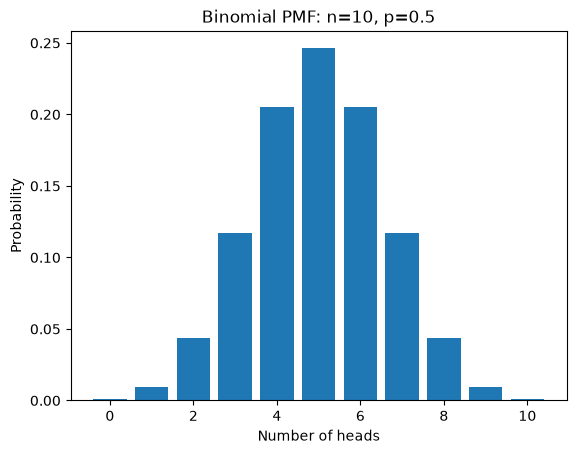

In [13]:
n = 10
p = 0.5
k = 5

manual = (math.factorial(n) / (math.factorial(k) * math.factorial(n-k))
          * p**k * (1-p)**(n-k))
scipy_answer = stats.binom.pmf(k, n, p)
print(manual, scipy_answer)

possible_successes = np.arange(n + 1)  # 0 through n
probabilities = stats.binom.pmf(possible_successes, n, p)
plt.bar(possible_successes, probabilities)
plt.xlabel("Number of heads")
plt.ylabel("Probability")
plt.title(f"Binomial PMF: n={n}, p={p}")
plt.show()


## Negative binomial distribution

Use when trials continue until the `n`-th success and `k` counts the failures before stopping.

$$P(K=k)=\binom{k+n-1}{k}p^n(1-p)^k.$$

SciPy syntax: `stats.nbinom.pmf(k, n, p)`.

> **Important correction:** Lecture 5's exercise text describes `p` as the success probability but displays the powers as $p^k(1-p)^n$. Under that definition, the correct powers are $p^n(1-p)^k$, matching SciPy. For a fair coin (`p=.5`) the numerical answer is unchanged, which can hide the typo.

Binomial versus negative binomial:

| Question | Fixed quantity | Random/count quantity |
|---|---|---|
| Binomial | number of trials `n` | successes `k` |
| Negative binomial | target successes `n` | failures `k` before target |


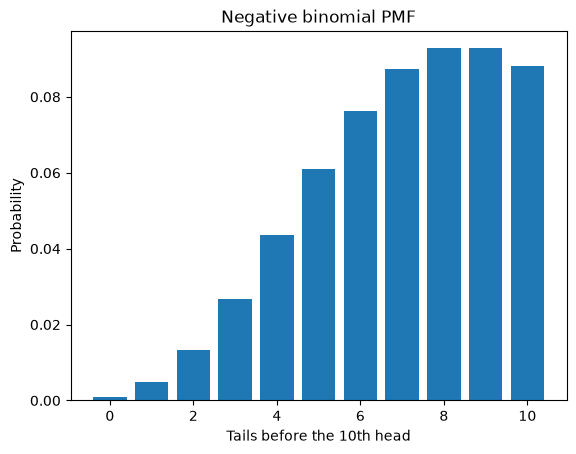

In [14]:
# Probability distribution for 0–10 tails before the 10th head
n_successes = 10
p_success = 0.5
k_failures = np.arange(0, 11)
probabilities = stats.nbinom.pmf(k_failures, n_successes, p_success)

plt.bar(k_failures, probabilities)
plt.xlabel("Tails before the 10th head")
plt.ylabel("Probability")
plt.title("Negative binomial PMF")
plt.show()


## NumPy arrays versus lists

```python
[2, 3] + [1, 4]                       # [2, 3, 1, 4] (concatenation)
np.array([2, 3]) + np.array([1, 4])   # array([3, 7]) (elementwise addition)
```

Array operations `+`, `-`, `*`, `/`, and `**` are element by element for same-shaped arrays. A scalar is applied to every entry (**broadcasting**).

Dividing arrays by zero usually produces `nan` (`0/0`) or `inf` (nonzero/0) plus a warning rather than stopping execution.

Likewise, a negative base raised to a non-integer real exponent (for example `(-3)**1.2`) is not a real number, so a real-valued NumPy array may return `nan` with a warning. That warning is expected in the Lecture 5 vector exercise.


In [15]:
a = np.array([2, 1.2, 3.4])
b = np.array([2.2, -3, 10.01])

c = a * b
d = 5 - a
e = (a - b) / 2
f = b ** a
g = 2 ** a
h = np.exp(a + b)

print("c =", c)
print("d =", d)
print("e =", e)
print("f =", f)
print("g =", g)
print("h =", h)


c = [ 4.4   -3.6   34.034]
d = [3.  3.8 1.6]
e = [-0.1    2.1   -3.305]
f = [   4.84                 nan 2520.43709866]
g = [ 4.          2.29739671 10.55606329]
h = [6.66863310e+01 1.65298888e-01 6.66636367e+05]


/var/folders/rr/sv5mmf_12pl3_4jd28mkfn4h0000gn/T/ipykernel_27397/2403566293.py:7: RuntimeWarning: invalid value encountered in power
  f = b ** a


## NumPy math and constants

- `np.log(x)` = natural log $\ln(x)$
- `np.exp(x)` = $e^x$
- `np.sin(x)`, `np.cos(x)` use **radians**
- `np.sqrt(x)` = square root
- `np.pi`, `np.e` are constants

Always translate mathematical grouping with parentheses. Example:

$$\ln\left(\frac{2x+1}{x+2}\right)$$

becomes `np.log((2*x + 1) / (x + 2))`.

## Plotting a mathematical function

1. Create x-values as a NumPy array.
2. Calculate all y-values with one vectorized expression.
3. Plot and label.

`np.linspace(start, stop, number_of_points)` is convenient and includes both endpoints by default.


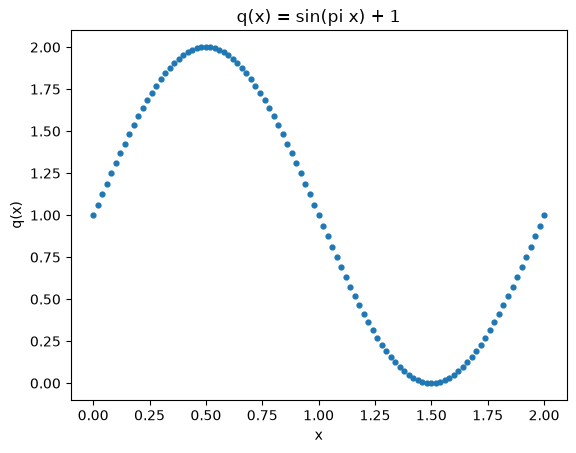

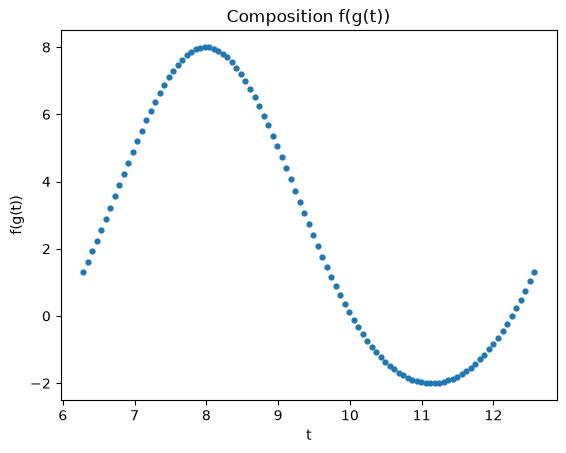

In [16]:
# q(x) = sin(pi*x) + 1 on [0, 2]
x = np.linspace(0, 2, 101)
q = np.sin(np.pi * x) + 1

plt.scatter(x, q, s=12)
plt.xlabel("x")
plt.ylabel("q(x)")
plt.title("q(x) = sin(pi x) + 1")
plt.show()

# Composition: f(g(t)), where f(x)=x^2-5x+2 and g(t)=sin(t+3)
t = np.linspace(2*np.pi, 4*np.pi, 101)
g = np.sin(t + 3)
f_of_g = g**2 - 5*g + 2

plt.scatter(t, f_of_g, s=12)
plt.xlabel("t")
plt.ylabel("f(g(t))")
plt.title("Composition f(g(t))")
plt.show()


# 7. Common errors and traps

| Symptom/error | Likely cause | Fix |
|---|---|---|
| `NameError` | variable/function not defined; cell not run; wrong capitalization | run defining cell; check spelling/case |
| `ModuleNotFoundError` | package unavailable in selected environment | select correct environment/install package |
| `TypeError` | operation/function received wrong type | inspect with `type()` and convert if appropriate |
| `IndexError` | list index outside valid range | for length `n`, valid positive indices are `0` to `n-1` |
| `SyntaxError` | invalid Python grammar | check quotes, commas, parentheses, and argument order |
| `L` unexpectedly becomes `None` | wrote `L = L.sort()`/`append()`/`reverse()` | call mutating method without assignment |
| Changing copied list changes original | used `copy = original` | use `copy = original.copy()` |
| `0.1+0.1+0.1 == 0.3` is false | floating-point approximation | use tolerance or `np.isclose` |
| Logic gives surprising `True` | used string `"False"`, or unclear precedence | use Boolean `False`; add parentheses |
| `math.sqrt(list)` fails | scalar function received a list | use `np.sqrt(list_or_array)` |
| Arrays do not combine as expected | confused list concatenation with array math | convert using `np.array(...)` |
| Random result changes | no fixed seed, or generator state advanced | set seed once for reproducible sequence |

## Before submitting a quiz answer

1. Predict the **type** and shape of the result.
2. Check indexing starts at 0.
3. Distinguish assignment `=` from comparison `==`.
4. Check strings versus numbers and strings versus Booleans.
5. Check whether a method mutates an object or returns a new value.
6. Add parentheses to reflect the mathematical formula.
7. For probability, identify what `n`, `k`, and `p` mean before choosing a distribution.
8. Run the exact cell and inspect output/error.


# 8. Practice questions — predict first, then reveal

## Questions

1. What are the outputs of `35 / 8`, `35 // 8`, and `35 % 8`?
2. What does `[1,2] + [3,4]` return? What about `np.array([1,2]) + np.array([3,4])`?
3. After `a=[1,2]; b=a; a[0]=9`, what is `b`? How would you prevent that?
4. Why can `0.1 + 0.1 + 0.1 == 0.3` be false?
5. What is the difference among `choice`, `choices`, and `sample`?
6. Does `random.randint(1,6)` ever return 6?
7. When do you use binomial versus negative binomial?
8. What does `np.argmax([7.5, 9.0, 4.5])` return?
9. Why is `x = x.sort()` usually wrong for a list?
10. Evaluate the types/results: `str(abs(-3)+5)`, `str(abs(-3))+'5'`, and `int(abs(-3)<5)`.

<details>
<summary><strong>Click to reveal answers</strong></summary>

1. `4.375`, `4`, `3`.
2. `[1, 2, 3, 4]`; `array([4, 6])`.
3. `[9, 2]`, because `a` and `b` alias the same list. Use `b = a.copy()`.
4. Binary floating-point stores approximations; compare within a tolerance.
5. `choice`: one item; `choices`: multiple with replacement; `sample`: multiple without replacement.
6. Yes—both endpoints are included.
7. Binomial: fixed trials, count successes. Negative binomial: stop at fixed successes, count failures before stopping.
8. `1`, the index of the largest value—not the value `9.0`.
9. `sort()` mutates the list and returns `None`, so the assignment replaces `x` with `None`.
10. `"8"` (string), `"35"` (string concatenation), `1` (`True` converted to integer).

</details>


# Final one-screen checklist

- **Need data?** `pd.read_csv`, `df["col"]`, `describe`, `crosstab`.
- **Need a graph?** build x/y → `plt.scatter` or `plt.bar` → labels/title → `show`.
- **Need one list item?** zero-based index; negative index from end.
- **Need a copy?** `.copy()`, not plain assignment.
- **Need a condition?** comparison → Boolean → combine using `not`/`and`/`or`/`^`.
- **Need numerical operations on many values?** `np.array` and NumPy functions.
- **Need randomness?** decide with/without replacement; seed for reproducibility.
- **Need probability?** fixed trials = binomial; fixed target successes = negative binomial.
- **Unexpected answer?** inspect `type(...)`, parentheses, mutation, floating-point precision, and whether all prerequisite cells ran.

Good luck—you can use **Ctrl/Cmd + F** to jump directly to any command during the quiz.
